# Flagging — discursive functions per window

Reads a flagging manifest and marks each 5-second window with the discursive
functions it realises, then pools per video and per corpus.

**The rule** (`FLAGS SYS X ABEL.xlsx`): a window earns a flag when at least
`min_elements` of that flag's specified elements match **and** at least one
element from each required macro-category matches. Elements a flag does not
specify are not evaluated and cannot count.

Nothing here is hardcoded — the flags, the categories, the word lists and the
threshold all come from the manifest (`flags/*.yaml`, see its HANDBOOK.md).
Change the rules there, re-run, compare.

**Read section 2 before any flag count.** Verbal coverage is the ceiling on
every flag that needs a subject or a verb, and it is a property of the
language as much as of the speaker.

In [1]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import _corpus as C
from core.flagging import Manifest
from core.flag_runner import (
    run_corpus, window_table, summary_table, overlap_table, to_excel,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 70)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9})

CORPUS = "Ted"
MANIFEST = "../flags/multiarth_cda.yaml"
EXPORT_DIR = Path("../flag_reports") / CORPUS

manifest = Manifest.from_yaml(MANIFEST)
print(f"manifest {manifest.id} v{manifest.version}  (sha {manifest.sha256[:12]})")
print(f"  {len(manifest.flags)} flags, {len(manifest.variables)} variables, "
      f"{len(manifest.lexicons)} lexicons")
print(f"  rule: {manifest.min_elements} elements, one each from "
      f"{', '.join(manifest.require_each_macro)}")

manifest multiarth-cda v4  (sha 662c467da262)
  10 flags, 6 variables, 17 lexicons
  rule: 5 elements, one each from verbal, camera, acoustic, gesture


## 1. The rulebook

What the manifest asks for, before looking at any data. The `criteria` count
matters: a flag needing 5 matches out of 6 specified elements is far stricter
than one with 10 specified, even though both say `min_elements: 5`.

In [2]:
rules = pd.DataFrame([
    {"Flag": f.id, "Name": f.name,
     "Criteria": len(f.criteria),
     "Needs": f.min_elements or manifest.min_elements,
     "Strictness": round((f.min_elements or manifest.min_elements) / len(f.criteria), 2),
     "Elements": ", ".join(sorted(f.criteria)),
     } for f in manifest.flags])
display(rules.sort_values("Strictness", ascending=False))

,Flag,Name,Criteria,Needs,Strictness,Elements
4,F5,Affective-persuasive,6,5,0.83,"horizontal, pitch_variation, shot, subject, verb, wrist_velocity"
1,F2,Individual material action,7,5,0.71,"horizontal, pitch_variation, shot, subject, verb, vertical, wrist_..."
8,F9,Women / feminism as patient,7,5,0.71,"horizontal, object, pitch_variation, shot, verb, vertical, wrist_v..."
2,F3,Collective material action,7,5,0.71,"horizontal, pitch_variation, shot, subject, verb, vertical, wrist_..."
9,F10,Neutral distance,7,5,0.71,"pitch_level, pitch_variation, shot, subject, verb, vertical, wrist..."
0,F1,Individual intellectual authority,8,5,0.62,"horizontal, pitch_level, pitch_variation, shot, subject, verb, ver..."
5,F6,Personal-experiential,8,5,0.62,"horizontal, pitch_level, pitch_variation, shot, subject, verb, ver..."
3,F4,Collective theorisation,8,5,0.62,"horizontal, pitch_level, pitch_variation, shot, subject, verb, ver..."
7,F8,Women / feminism as agent,8,5,0.62,"horizontal, pitch_level, pitch_variation, shot, subject, verb, ver..."
6,F7,Construction of non-human concepts,8,5,0.62,"horizontal, pitch_level, pitch_variation, shot, subject, verb, ver..."


## 2. Verbal coverage — the ceiling

How often each verbal slot could be filled at all. A flag requiring a subject
can never exceed the share of windows that have one, so this bounds everything
below.

Two separate causes of a low number, worth telling apart:

* **the word lists** — a subject is present but not in any lexicon;
* **the language** — Mandarin routinely omits the subject altogether, so a
  Chinese corpus will show a structurally lower figure than an English one,
  for reasons of grammar rather than of style.

In [3]:
data = C.load_corpus(CORPUS)
windows = data.windows
print(f"{len(windows)} windows across {windows.job_id.nunique()} videos")

runs = run_corpus(windows, manifest, labels={j: data.label(j) for j in data.videos.job_id},
                  progress=False)
print(f"flagged {len(runs)} videos")

coverage = {}
for run in runs.values():
    for element, stats in (run.get("verbal_coverage") or {}).items():
        if isinstance(stats, dict) and "filled" in stats:
            entry = coverage.setdefault(element, [0, 0])
            entry[0] += stats["filled"]
            entry[1] += run["summary"]["n_windows"]

cov = pd.DataFrame([{"Element": name, "Windows filled": filled, "Total": total,
                     "% filled": round(100 * filled / max(total, 1), 1)}
                    for name, (filled, total) in coverage.items()])
display(cov)

/home/abx13/Prog/Mannerism-Analyzer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
loading TedX: 4/4 |██████████| , cache hit


loaded from cache: /home/abx13/.local/share/mannerism/corpus_cache/TedX_94fcfd3229ddfc2f.pkl
6013 windows across 39 videos
flagged 39 videos


,Element,Windows filled,Total,% filled
0,subject,3554,6013,59.1
1,object,1999,6013,33.2
2,verb,5308,6013,88.3


## 3. How much was flagged

A window may carry several flags, so the shares below sum to more than the
share of flagged windows.

1343 of 6013 windows carry at least one flag (22.3%)


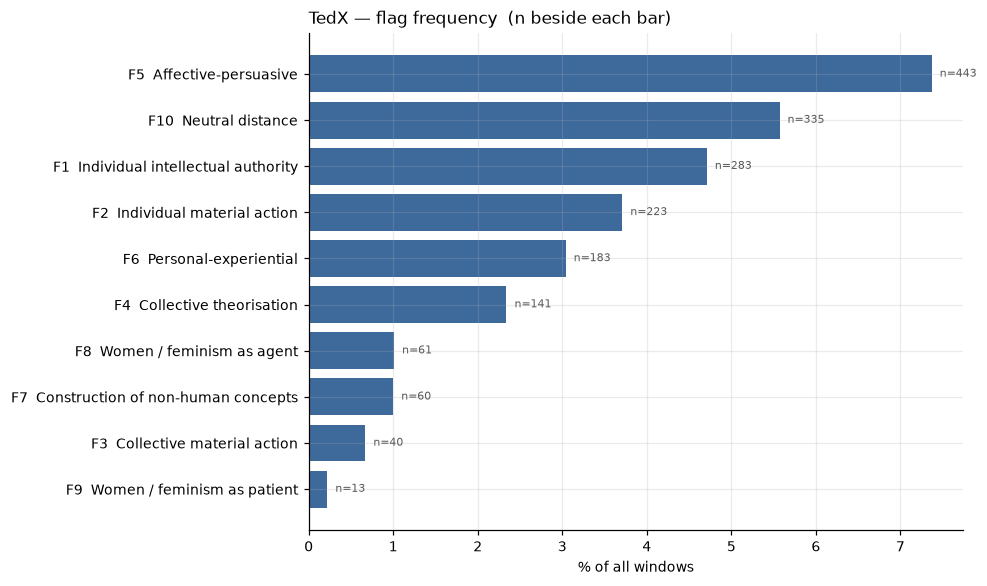

,Flag,Name,Windows,% of windows
4,F5,Affective-persuasive,443,7.37
9,F10,Neutral distance,335,5.57
0,F1,Individual intellectual authority,283,4.71
1,F2,Individual material action,223,3.71
5,F6,Personal-experiential,183,3.04
3,F4,Collective theorisation,141,2.34
7,F8,Women / feminism as agent,61,1.01
6,F7,Construction of non-human concepts,60,1.00
2,F3,Collective material action,40,0.67
8,F9,Women / feminism as patient,13,0.22


In [4]:
pooled = {}
for run in runs.values():
    for fid, rec in run["summary"]["by_flag"].items():
        entry = pooled.setdefault(fid, {"Name": rec["name"], "Windows": 0})
        entry["Windows"] += rec["n"]

total_windows = sum(r["summary"]["n_windows"] for r in runs.values())
total_flagged = sum(r["summary"]["flagged_windows"] for r in runs.values())
print(f"{total_flagged} of {total_windows} windows carry at least one flag "
      f"({100 * total_flagged / max(total_windows, 1):.1f}%)")

freq = pd.DataFrame([{"Flag": fid, **rec} for fid, rec in pooled.items()])
freq["% of windows"] = (100 * freq.Windows / total_windows).round(2)
freq = freq.sort_values("Windows", ascending=False)

fig, ax = plt.subplots(figsize=(9, 0.42 * len(freq) + 1.2))
ax.barh(freq.Flag[::-1] + "  " + freq.Name[::-1].str.slice(0, 34),
        freq["% of windows"][::-1], color="#1B4F8A", alpha=0.85)
for y, (_, r) in enumerate(freq[::-1].iterrows()):
    ax.text(r["% of windows"], y, f"  n={int(r.Windows)}", va="center",
            fontsize=7, color="0.35")
ax.set_xlabel("% of all windows")
ax.set_title(f"{CORPUS} — flag frequency  (n beside each bar)", loc="left")
plt.tight_layout(); plt.show()
display(freq[["Flag", "Name", "Windows", "% of windows"]])

## 4. One video in detail

The table from `DEF_Practical Example x Video`: one row per window, the four
macro-categories, the flags, and the evidence behind each flag. `Evidence`
reads `F1: 6/10 [subject, shot, …]` — six of the ten elements F1 specifies
matched, and these are they.

In [5]:
JOB = None      # None -> the video with the most flags

if JOB is None:
    JOB = max(runs, key=lambda j: runs[j]["summary"]["flagged_windows"])
run = runs[JOB]
print(f"{JOB} — {data.label(JOB)[:60]}")
print(f"{run['summary']['flagged_windows']} of {run['summary']['n_windows']} "
      f"windows flagged")

table = window_table(run, manifest)
display(table[table.FLAG != ""].head(15))

b679bf9d — 37 A Seat at the Table Isn't the Solution for Gender Equity 
72 of 240 windows flagged


,Timestamp,Transcript,Verbal,Camera,Acoustic,Gesture,FLAG,Flag names,Evidence
2,00:00:10–00:00:15,"in India didn't find out for two weeks, which is a shame, because,...",subject: first_singular; object: proper_nouns; verb: first_singula...,shot: close_up; horizontal: frontal; vertical: low,pitch_level: medium; pitch_variation: varying,wrist_velocity: medium,F5,Affective-persuasive,"F5: 5/6 [subject, shot, horizontal, pitch_variation, wrist_velocity]"
3,00:00:15–00:00:20,was. And it's not because the phone lines were down or because,"subject: other_pronouns; verb: other_pronouns, presentation_verbs",shot: very_long; horizontal: frontal; vertical: eye_level,pitch_level: low; pitch_variation: steady,wrist_velocity: low,F10,Neutral distance,"F10: 5/7 [verb, shot, pitch_level, pitch_variation, wrist_velocity]"
5,00:00:25–00:00:30,"was being assigned female at birth. You see, because my","subject: second_person; verb: first_singular, perception_verbs, pr...",shot: close_up; horizontal: transitional; vertical: low,pitch_level: low; pitch_variation: steady,wrist_velocity: medium,F6,Personal-experiential,"F6: 6/8 [verb, shot, horizontal, pitch_level, pitch_variation, wri..."
10,00:00:50–00:00:55,"Just the reality that from the moment I came into this world, I was","subject: first_singular; verb: first_singular, presentation_verbs",shot: close_up; horizontal: transitional; vertical: low,pitch_level: low; pitch_variation: steady,wrist_velocity: low,F10,Neutral distance,"F10: 5/7 [verb, vertical, pitch_level, pitch_variation, wrist_velo..."
18,00:01:30–00:01:35,set me on a lifetime mission of trying to prove myself and just fe...,"object: first_singular; verb: first_singular, perception_verbs, pr...",shot: medium_close; horizontal: frontal; vertical: low,pitch_level: low; pitch_variation: steady,wrist_velocity: low,F10,Neutral distance,"F10: 5/7 [verb, vertical, pitch_level, pitch_variation, wrist_velo..."
24,00:02:00–00:02:05,"say, if there is no seat, drag your own seat. I'm sure you've hear...","subject: first_singular, second_person; verb: first_singular, perc...",shot: close_up; horizontal: oblique; vertical: low,pitch_level: high; pitch_variation: varying,wrist_velocity: high,F2,Individual material action,"F2: 5/7 [subject, shot, vertical, pitch_variation, wrist_velocity]"
26,00:02:10–00:02:15,necessary. And that's been the driving force behind my entire career.,"verb: causal_verbs, first_singular, presentation_verbs",shot: close_up; horizontal: frontal; vertical: low,pitch_level: low; pitch_variation: steady,wrist_velocity: medium,F7,Construction of non-human concepts,"F7: 7/8 [verb, shot, horizontal, vertical, pitch_level, pitch_vari..."
27,00:02:15–00:02:20,"Now, in 2010, I noticed that no one on YouTube looked like me.","subject: first_singular, generic_subjects; object: first_singular,...",shot: long; horizontal: frontal; vertical: low,pitch_level: medium; pitch_variation: varying,wrist_velocity: high,F2,Individual material action,"F2: 5/7 [subject, horizontal, vertical, pitch_variation, wrist_vel..."
29,00:02:25–00:02:30,take on the world. There was no me in front of a camera. I saw a s...,subject: first_singular; object: first_singular; verb: first_singu...,shot: medium_close; horizontal: frontal; vertical: low,pitch_level: medium; pitch_variation: varying,wrist_velocity: medium,F5,Affective-persuasive,"F5: 5/6 [subject, shot, horizontal, pitch_variation, wrist_velocity]"
30,00:02:30–00:02:35,for grabs. So I got to work and I started a channel under the name...,"subject: first_singular; verb: first_singular, proper_nouns",shot: medium_close; horizontal: frontal; vertical: low,pitch_level: low; pitch_variation: varying,wrist_velocity: medium,F1 - F5,Individual intellectual authority; Affective-persuasive,"F1: 5/8 [subject, horizontal, vertical, pitch_level, wrist_velocit..."


## 5. Where the flags fall in the talk

One row per flag, a mark wherever it fires. Clustering matters: a function
concentrated in one passage is doing different work from one spread evenly
through the talk, and a pooled count cannot tell them apart.

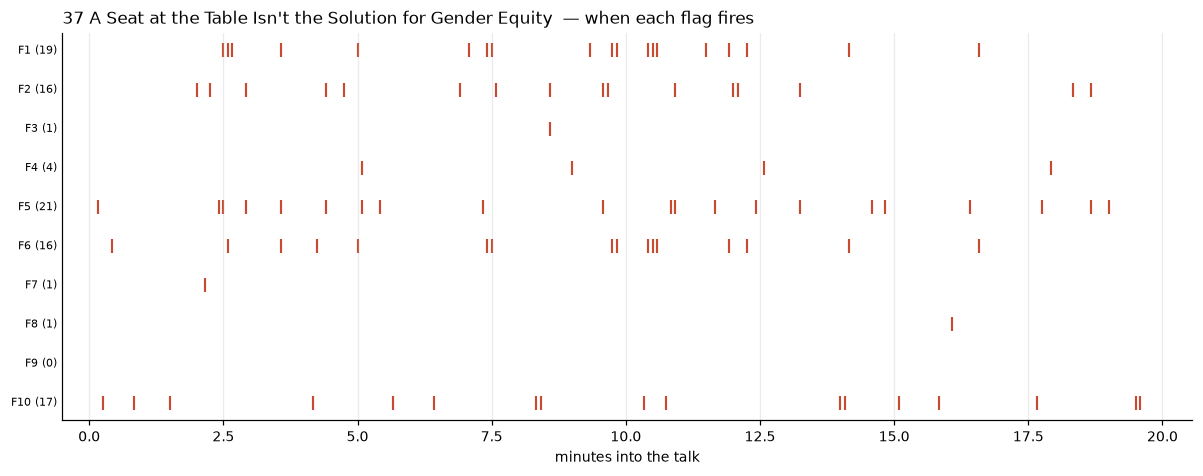

In [6]:
ids = [f.id for f in manifest.flags]
marks = {fid: [] for fid in ids}
for record in run["windows"]:
    for rec in record["flags"]:
        marks[rec["id"]].append(record["t"][0] / 60)

fig, ax = plt.subplots(figsize=(11, 0.32 * len(ids) + 1.2))
for y, fid in enumerate(ids[::-1]):
    xs = marks[fid]
    ax.scatter(xs, [y] * len(xs), marker="|", s=90, linewidths=1.4,
               color="#C84B31" if xs else "0.8")
    ax.text(-0.6, y, f"{fid} ({len(xs)})", ha="right", va="center", fontsize=7)
ax.set_yticks([]); ax.set_xlabel("minutes into the talk")
ax.set_xlim(left=-0.5)
ax.set_title(f"{data.label(JOB)[:60]} — when each flag fires", loc="left")
plt.tight_layout(); plt.show()

## 6. Overlaps — predicted against observed

`DEF_OVERLAPS` works out by hand which flag pairs *can* co-occur: 19 of the 45
possible pairs, of which 7 are residual. The manifest declares that
classification, and this measures what actually happened.

Two readings worth making:

* an **unexpected** pair occurring often means two functions are less distinct
  than the design assumed;
* a **designed** pair that never occurs means the corpus does not contain that
  combination — a finding about the material, not about the rules.

In [7]:
pairs = {}
for r in runs.values():
    for pair, n in r["summary"]["pairs"].items():
        pairs[pair] = pairs.get(pair, 0) + n

rows = []
seen = set()
for pair, n in pairs.items():
    a, b = pair.split("|"); seen.add(frozenset((a, b)))
    rows.append({"Pair": f"{a}–{b}", "Expected": manifest.overlap_kind(a, b), "Windows": n})
for kind, declared in manifest.expected_overlaps.items():
    for pair in declared:
        if pair not in seen:
            a, b = sorted(pair)
            rows.append({"Pair": f"{a}–{b}", "Expected": kind, "Windows": 0})
ov = pd.DataFrame(rows).sort_values("Windows", ascending=False)

n_flags = len(manifest.flags)
print(f"{int((ov.Windows > 0).sum())} of {n_flags * (n_flags - 1) // 2} possible "
      f"pairs observed; manifest declared {sum(len(v) for v in manifest.expected_overlaps.values())}")
display(ov.groupby("Expected").agg(pairs=("Pair", "count"),
                                   windows=("Windows", "sum")).sort_values("windows", ascending=False))
display(ov.head(15))

17 of 45 possible pairs observed; manifest declared 19


,pairs,windows
Expected,,
designed,6,212
related,6,197
residual,7,76


,Pair,Expected,Windows
1,F1–F6,related,149
0,F2–F5,designed,116
6,F4–F5,designed,66
4,F1–F5,residual,29
5,F5–F6,residual,22
2,F3–F5,designed,18
9,F2–F8,related,16
3,F2–F3,related,15
7,F1–F4,related,15
12,F10–F7,residual,11


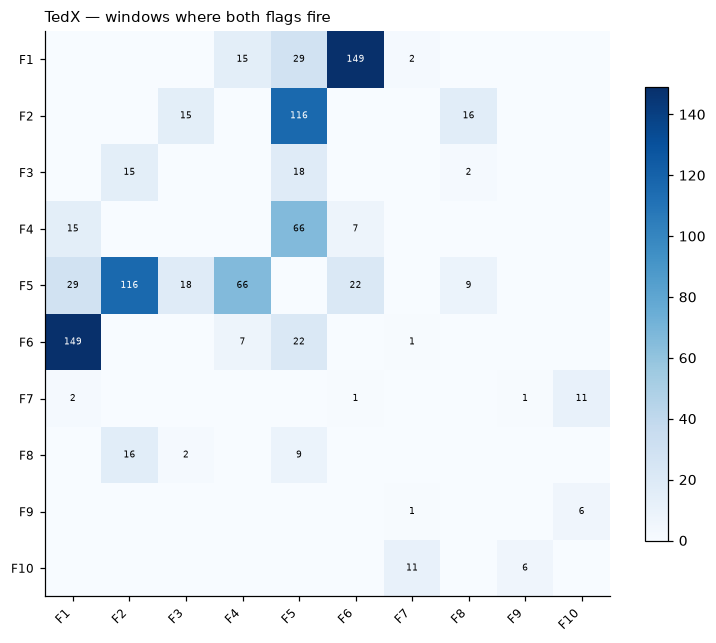

In [8]:
# The same thing as a matrix, which is easier to scan for structure.
mat = pd.DataFrame(0, index=ids, columns=ids)
for pair, n in pairs.items():
    a, b = pair.split("|")
    mat.loc[a, b] = n; mat.loc[b, a] = n

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(mat.values, cmap="Blues")
ax.set_xticks(range(len(ids)), ids, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(ids)), ids, fontsize=8)
ax.grid(False)
for i in range(len(ids)):
    for j in range(len(ids)):
        v = mat.values[i, j]
        if v:
            ax.text(j, i, str(v), ha="center", va="center", fontsize=6,
                    color="white" if v > mat.values.max() * 0.6 else "black")
ax.set_title(f"{CORPUS} — windows where both flags fire", loc="left", fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout(); plt.show()

## 7. Near misses — what is blocking each flag

Flags that fell one element short, and which element failed most often. This
is the tuning instrument: if one element blocks most near misses, that element
— usually a word list — is the bottleneck, not the threshold.

In [9]:
near = {}
for r in runs.values():
    for fid, rec in r["summary"]["near_miss"].items():
        entry = near.setdefault(fid, {"Near misses": 0, "missing": {}})
        entry["Near misses"] += rec["n"]
        for element, n in rec["missing"].items():
            entry["missing"][element] = entry["missing"].get(element, 0) + n

rows = []
for fid, rec in near.items():
    top = sorted(rec["missing"].items(), key=lambda kv: -kv[1])[:3]
    rows.append({"Flag": fid,
                 "Name": next((f.name for f in manifest.flags if f.id == fid), fid),
                 "Flagged": pooled.get(fid, {}).get("Windows", 0),
                 "Near misses": rec["Near misses"],
                 "Blocked by": ", ".join(f"{k} ({v})" for k, v in top)})
display(pd.DataFrame(rows).sort_values("Near misses", ascending=False))

,Flag,Name,Flagged,Near misses,Blocked by
2,F7,Construction of non-human concepts,60,3892,"subject (3876), verb (3866), pitch_variation (1463)"
3,F8,Women / feminism as agent,61,3266,"verb (3223), subject (3148), wrist_velocity (1789)"
8,F1,Individual intellectual authority,283,2694,"verb (2324), subject (1869), wrist_velocity (1589)"
4,F2,Individual material action,223,2123,"verb (1903), subject (1349), wrist_velocity (1119)"
6,F6,Personal-experiential,183,1533,"verb (1319), vertical (1143), subject (997)"
1,F5,Affective-persuasive,443,1439,"verb (1415), subject (619), pitch_variation (382)"
7,F10,Neutral distance,335,1218,"subject (1163), shot (628), wrist_velocity (498)"
0,F4,Collective theorisation,141,984,"verb (781), subject (694), vertical (673)"
5,F3,Collective material action,40,505,"verb (400), subject (300), vertical (260)"
9,F9,Women / feminism as patient,13,299,"vertical (299), verb (260), object (235)"


## 8. What a different threshold would do

The 5-of-8 rule is a judgement, not a measurement, so it is worth seeing its
sensitivity. This re-evaluates the same profiles at neighbouring thresholds —
cheap, because only the counting changes.

A threshold that doubles the flag count for one step is not discriminating;
one that barely moves it is not doing much work either.

,min_elements,windows flagged,% of windows
0,3,1890,31.4
1,4,1890,31.4
2,5,1343,22.3
3,6,499,8.3
4,7,101,1.7


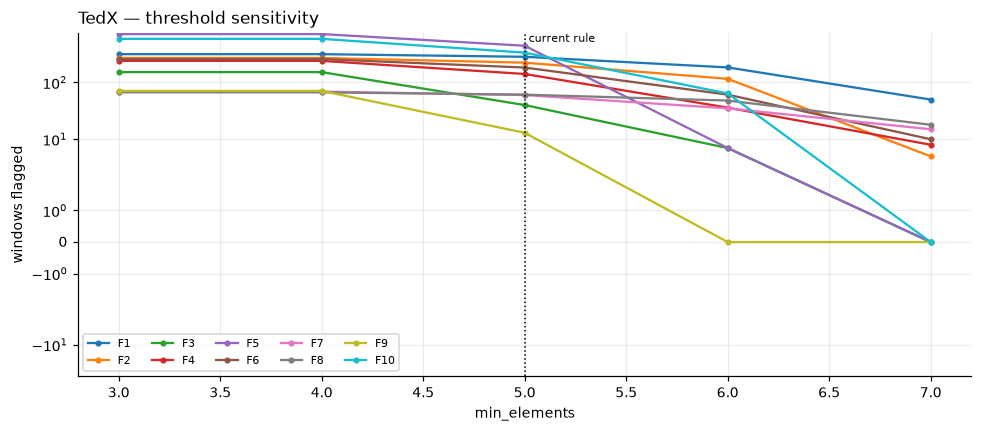

In [10]:
from copy import deepcopy
from core.flagging import evaluate_window

sensitivity = []
for threshold in range(max(2, manifest.min_elements - 2), manifest.min_elements + 3):
    variant = deepcopy(manifest)
    variant.min_elements = threshold
    for f in variant.flags:
        f.min_elements = None
    flagged = 0
    per_flag = {}
    for r in runs.values():
        for record in r["windows"]:
            result = evaluate_window(record["profile"], variant)
            if result["flags"]:
                flagged += 1
            for rec in result["flags"]:
                per_flag[rec["id"]] = per_flag.get(rec["id"], 0) + 1
    sensitivity.append({"min_elements": threshold,
                        "windows flagged": flagged,
                        "% of windows": round(100 * flagged / total_windows, 1),
                        **{k: per_flag.get(k, 0) for k in ids}})
sens = pd.DataFrame(sensitivity)
display(sens[["min_elements", "windows flagged", "% of windows"]])

fig, ax = plt.subplots(figsize=(9, 4))
for fid in ids:
    ax.plot(sens.min_elements, sens[fid], marker="o", ms=3, label=fid)
ax.axvline(manifest.min_elements, color="k", ls=":", lw=1)
ax.text(manifest.min_elements, ax.get_ylim()[1], " current rule", fontsize=7, va="top")
ax.set_xlabel("min_elements"); ax.set_ylabel("windows flagged")
ax.set_yscale("symlog")
ax.set_title(f"{CORPUS} — threshold sensitivity", loc="left")
ax.legend(fontsize=7, ncol=5)
plt.tight_layout(); plt.show()

## 9. Export

One workbook per video — Windows, Flag summary, Overlaps, Provenance. The last
sheet carries the manifest's id, version and hash and the threshold edges
actually used, which is what makes the other three checkable later.

In [ ]:
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
written = []
for job_id, r in runs.items():
    path = EXPORT_DIR / f"{job_id}__{manifest.id}_v{manifest.version}.xlsx"
    to_excel(r, manifest, path, label=data.label(job_id))
    written.append(path.name)
print(f"{len(written)} workbook(s) -> {EXPORT_DIR.resolve()}")
print("\n".join("  " + n for n in written[:5]) + ("\n  …" if len(written) > 5 else ""))

## Reading these results

* **Coverage first.** A flag's count is bounded by how often its elements could
  be filled at all; section 2 is not a formality.
* **A flag is not a claim about meaning.** It says a specified combination of
  features co-occurred, under thresholds computed per speaker. What that
  combination *means* is the qualitative reading the table is there to support.
* **Counts are not comparable across manifest versions.** The version and hash
  travel with every export for that reason.
* **Windows are 5 seconds and can hold more than one clause.** Any lexicon hit
  in the window fills its element, so subject and verb need not belong to the
  same clause. Tightening that would mean matching within a clause, which the
  parse supports but the current rule does not ask for.
* **Word lists are the lever.** Where a flag fires rarely, section 7 usually
  shows its verb or subject list is the binding constraint rather than the
  threshold.